# 01 — Recommender System Introduction

**Hour 2, 60–70 min: Understanding the data**

We're picking up the story from the slides: a movie streaming platform wants to recommend
movies to its users based on the patterns in what similar users have liked. Before we build
anything, we need to load the ratings data and understand its shape.

By the end of this notebook you will have:
- Loaded the movie ratings dataset
- Counted users, movies, and ratings
- Checked how sparse the data is (most users only rate a handful of movies)
- Visualized the most-rated movies, the rating distribution, and ratings-per-user

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (9, 5)

## Step 2 — Load the Dataset

`movie_ratings_dataset.csv` is a **synthetic** dataset built to feel like real movie ratings
data. Movie titles are entirely invented — this does not represent any real streaming
platform, user, or film.

In [2]:
ratings = pd.read_csv("../data/movie_ratings_dataset.csv")
ratings.shape

(3841, 5)

In [3]:
ratings.head()

,user_id,movie_id,movie_title,genre,rating
0,U158,M045,The Wedding Planner's Heart,Romance,5
1,U399,M036,Synthetic Dawn,Sci-Fi,4
2,U348,M038,Parallel Code,Sci-Fi,3
3,U314,M047,"Two Hearts, One City",Romance,4
4,U245,M054,Nightfall Manor,Horror,5


## Step 3 — Explore

Here's what each column means:

| Column | Meaning |
|---|---|
| `user_id` | Unique ID for the user who gave the rating |
| `movie_id` | Unique ID for the movie |
| `movie_title` | The movie's title |
| `genre` | The movie's genre (included for teaching purposes, to help us sanity-check our results) |
| `rating` | The user's rating, 1–5 (explicit feedback) |

In [4]:
n_users = ratings["user_id"].nunique()
n_movies = ratings["movie_id"].nunique()
n_ratings = len(ratings)

print(f"Users:   {n_users}")
print(f"Movies:  {n_movies}")
print(f"Ratings: {n_ratings}")

Users:   300
Movies:  60
Ratings: 3841


**How sparse is this data?** If every user had rated every movie, we'd have
`n_users x n_movies` ratings. Let's see what fraction of that is actually filled in.

In [5]:
max_possible = n_users * n_movies
sparsity = 1 - n_ratings / max_possible
print(f"Maximum possible user-movie pairs: {max_possible}")
print(f"Actual ratings given: {n_ratings}")
print(f"Sparsity: {sparsity*100:.1f}% of the matrix is EMPTY (unrated)")

Maximum possible user-movie pairs: 18000
Actual ratings given: 3841
Sparsity: 78.7% of the matrix is EMPTY (unrated)


**Business perspective:** Almost 4 out of every 5 possible user-movie pairs have no rating at all. This is completely normal for recommendation data — no user has time to watch and rate every movie on the platform. This is exactly the SPARSE DATA challenge from the slides, and it's the reason we can't simply 'look up' what a user thinks of an unrated movie — we have to predict it.

### Any missing values in the columns themselves?

In [6]:
ratings.isna().sum()

user_id        0
movie_id       0
movie_title    0
genre          0
rating         0
dtype: int64

No missing values in the columns we loaded — every row is a complete (user, movie, rating) record. The 'missing values' we care about for recommendations are the user-movie PAIRS that never appear as a row at all, which we already measured above as sparsity.

## Step 4 — Visualize Basic Information

### Rating distribution

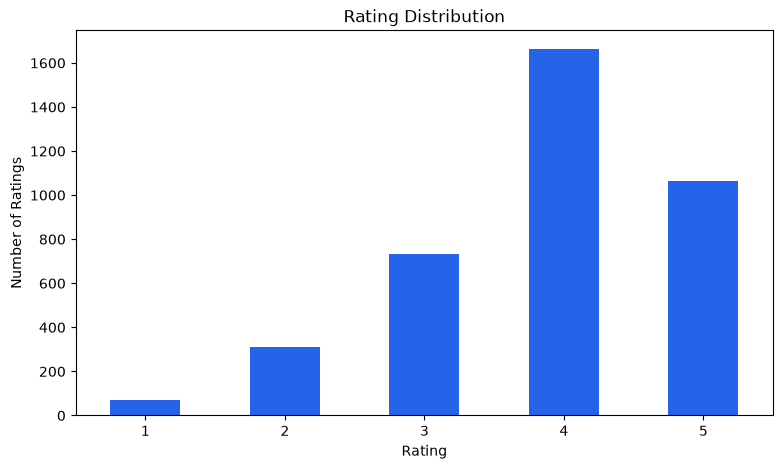

In [7]:
fig, ax = plt.subplots()
ratings["rating"].value_counts().sort_index().plot(kind="bar", color="#2563EB", ax=ax)
ax.set_xlabel("Rating")
ax.set_ylabel("Number of Ratings")
ax.set_title("Rating Distribution")
plt.xticks(rotation=0)
plt.show()

**What do we see?** Ratings skew toward the higher end — this makes sense: our synthetic users mostly rate movies they *chose to watch*, and they tend to choose movies in genres they already like.

### Most-rated movies

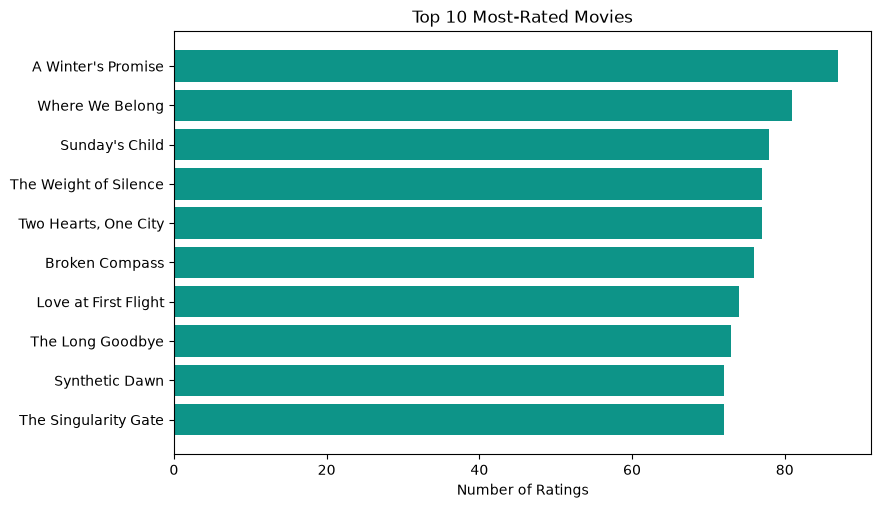

In [8]:
top_movies = ratings.groupby("movie_title").size().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(top_movies.index[::-1], top_movies.values[::-1], color="#0D9488")
ax.set_xlabel("Number of Ratings")
ax.set_title("Top 10 Most-Rated Movies")
plt.show()

### Number of ratings per user

How many movies does a typical user rate?

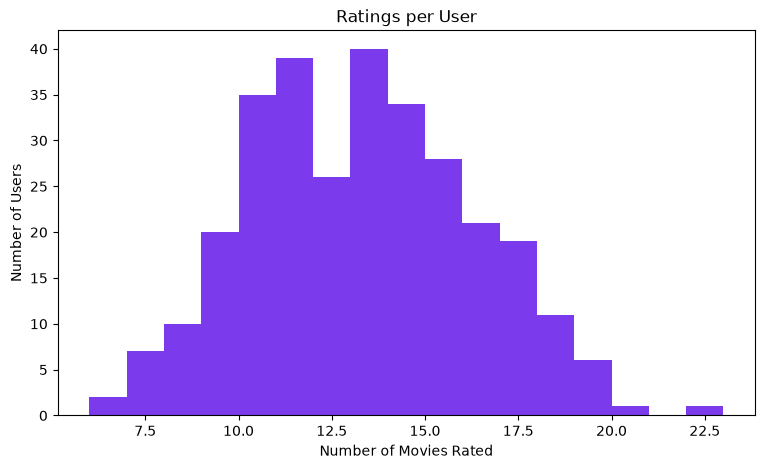

count    300.000000
mean      12.803333
std        2.985694
min        6.000000
25%       11.000000
50%       13.000000
75%       15.000000
max       22.000000
dtype: float64


In [9]:
ratings_per_user = ratings.groupby("user_id").size()

fig, ax = plt.subplots()
ax.hist(ratings_per_user, bins=range(ratings_per_user.min(), ratings_per_user.max() + 2), color="#7C3AED")
ax.set_xlabel("Number of Movies Rated")
ax.set_ylabel("Number of Users")
ax.set_title("Ratings per User")
plt.show()

print(ratings_per_user.describe())

**What do we see?** Most users rate somewhere between about 6 and 22 movies — a small
fraction of the full 60-movie catalog. This confirms, visually, the sparsity number we calculated above.

### Recap
- We loaded the ratings dataset and counted users, movies, and ratings.
- We measured sparsity directly — most user-movie pairs are unrated, which is the normal, expected
  situation for recommendation data.
- We visualized the rating distribution, the most-rated movies, and how many movies a typical
  user rates.

**Next: `02_User_Based_Collaborative_Filtering.ipynb`** — where we turn this data into a
user-item matrix and start finding similar users.